In [ ]:
#This code computes medians of errors and uses bootstrapping to calculate errors of medians

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.stats import bootstrap
sns.set_theme(context='paper', style='white', font="Helvetica", font_scale=1, color_codes=True, rc=None)
sns.set_style("ticks")

In [2]:
#Get and sort errors of interpolation
def get_errors(resolution):
    #read errors
    errors_inter_extrapolation=pd.read_csv('../../data/'+ 'errors_interpolation_' + resolution +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.", "n", "r"]
    errors_inter_extrapolation=errors_inter_extrapolation[columns]

    #divide between train/test
    errors_interpolation=errors_inter_extrapolation[["sigma","function", "rmse_nn_interp.", "rmse_mdl_interp.","n", "r"]]
    errors_interpolation=pd.melt(errors_interpolation,id_vars=["sigma","function", "n", "r"], var_name="error_interp.",
                                 value_name= "value_interp.")   

    errors_extrapolation=errors_inter_extrapolation[["sigma","function", "rmse_nn_extrap.", "rmse_mdl_extrap.","n", "r"]]
    errors_extrapolation=pd.melt(errors_extrapolation,id_vars= ["sigma","function", "n", "r"], var_name="error_extrap.", 
                                 value_name= "value_extrap.")

    #Separate tanh and leaky ReLU
    errors_t_tr=errors_interpolation[errors_interpolation['function']=='tanh']
    errors_t_tt=errors_extrapolation[errors_extrapolation['function']=='tanh']

    errors_l_tr=errors_interpolation[errors_interpolation['function']=='leaky_ReLU']
    errors_l_tt=errors_extrapolation[errors_extrapolation['function']=='leaky_ReLU']

    return errors_t_tr, errors_t_tt, errors_l_tr, errors_l_tt


In [3]:

resolutions=['1x', '2x', '4e-3x']

# Initialize combined DataFrames
combined_tanh_inter = pd.DataFrame()
combined_tanh_extra = pd.DataFrame()
combined_leaky_inter = pd.DataFrame()
combined_leaky_extra = pd.DataFrame()

# Load and combine data for each resolution
for resolution in resolutions:
    errors_tanh_inter, errors_tanh_extra, errors_leaky_inter, errors_leaky_extra = get_errors(resolution)
    
    # Add resolution identifier
    errors_tanh_inter['resolution'] = resolution
    errors_tanh_extra['resolution'] = resolution
    errors_leaky_inter['resolution'] = resolution
    errors_leaky_extra['resolution'] = resolution
    
    # Combine DataFrames
    combined_tanh_inter = pd.concat([combined_tanh_inter, errors_tanh_inter])
    combined_tanh_extra = pd.concat([combined_tanh_extra, errors_tanh_extra])
    combined_leaky_inter = pd.concat([combined_leaky_inter, errors_leaky_inter])
    combined_leaky_extra = pd.concat([combined_leaky_extra, errors_leaky_extra])

display(combined_tanh_inter)

,sigma,function,n,r,error_interp.,value_interp.,resolution
0,0.0,tanh,0,0,rmse_nn_interp.,0.012386,1x
1,0.0,tanh,1,0,rmse_nn_interp.,0.012122,1x
2,0.0,tanh,2,0,rmse_nn_interp.,0.006643,1x
3,0.0,tanh,3,0,rmse_nn_interp.,0.001461,1x
4,0.0,tanh,4,0,rmse_nn_interp.,0.002459,1x
...,...,...,...,...,...,...,...
985,0.2,tanh,5,2,rmse_mdl_interp.,0.037712,4e-3x
986,0.2,tanh,6,2,rmse_mdl_interp.,0.034507,4e-3x
987,0.2,tanh,7,2,rmse_mdl_interp.,0.019437,4e-3x
988,0.2,tanh,8,2,rmse_mdl_interp.,0.022793,4e-3x


In [4]:
#Plot results
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 16*cm; height=16*cm

Extensions=['.png', '.pdf']

#colors from seaborn's colorblind palette
color_data=sns.color_palette("colorblind")[0]
color_noise=sns.color_palette("colorblind")[7]
color_ann=sns.color_palette("colorblind")[4]
color_bms=sns.color_palette("colorblind")[2]

colors={'4e-3x':['#fee0d2', '#deebf7'],
       '2x':['#fc9272', '#9ecae1'],
       '1x':['#de2d26', '#3182bd'] }

#Fonts and sizes                                                                                    
size_axis=12;size_ticks=10;size_title=5
line_w=1;marker_s=3 #width and marker size                                                          

markers = {'rmse_nn_interp.': 'o', 'rmse_mdl_interp.': 's'}; m_size=6

output_path='../../results/'

resamples=100000; bs_seed=1111
ymin=1e-4;ymax=1.15

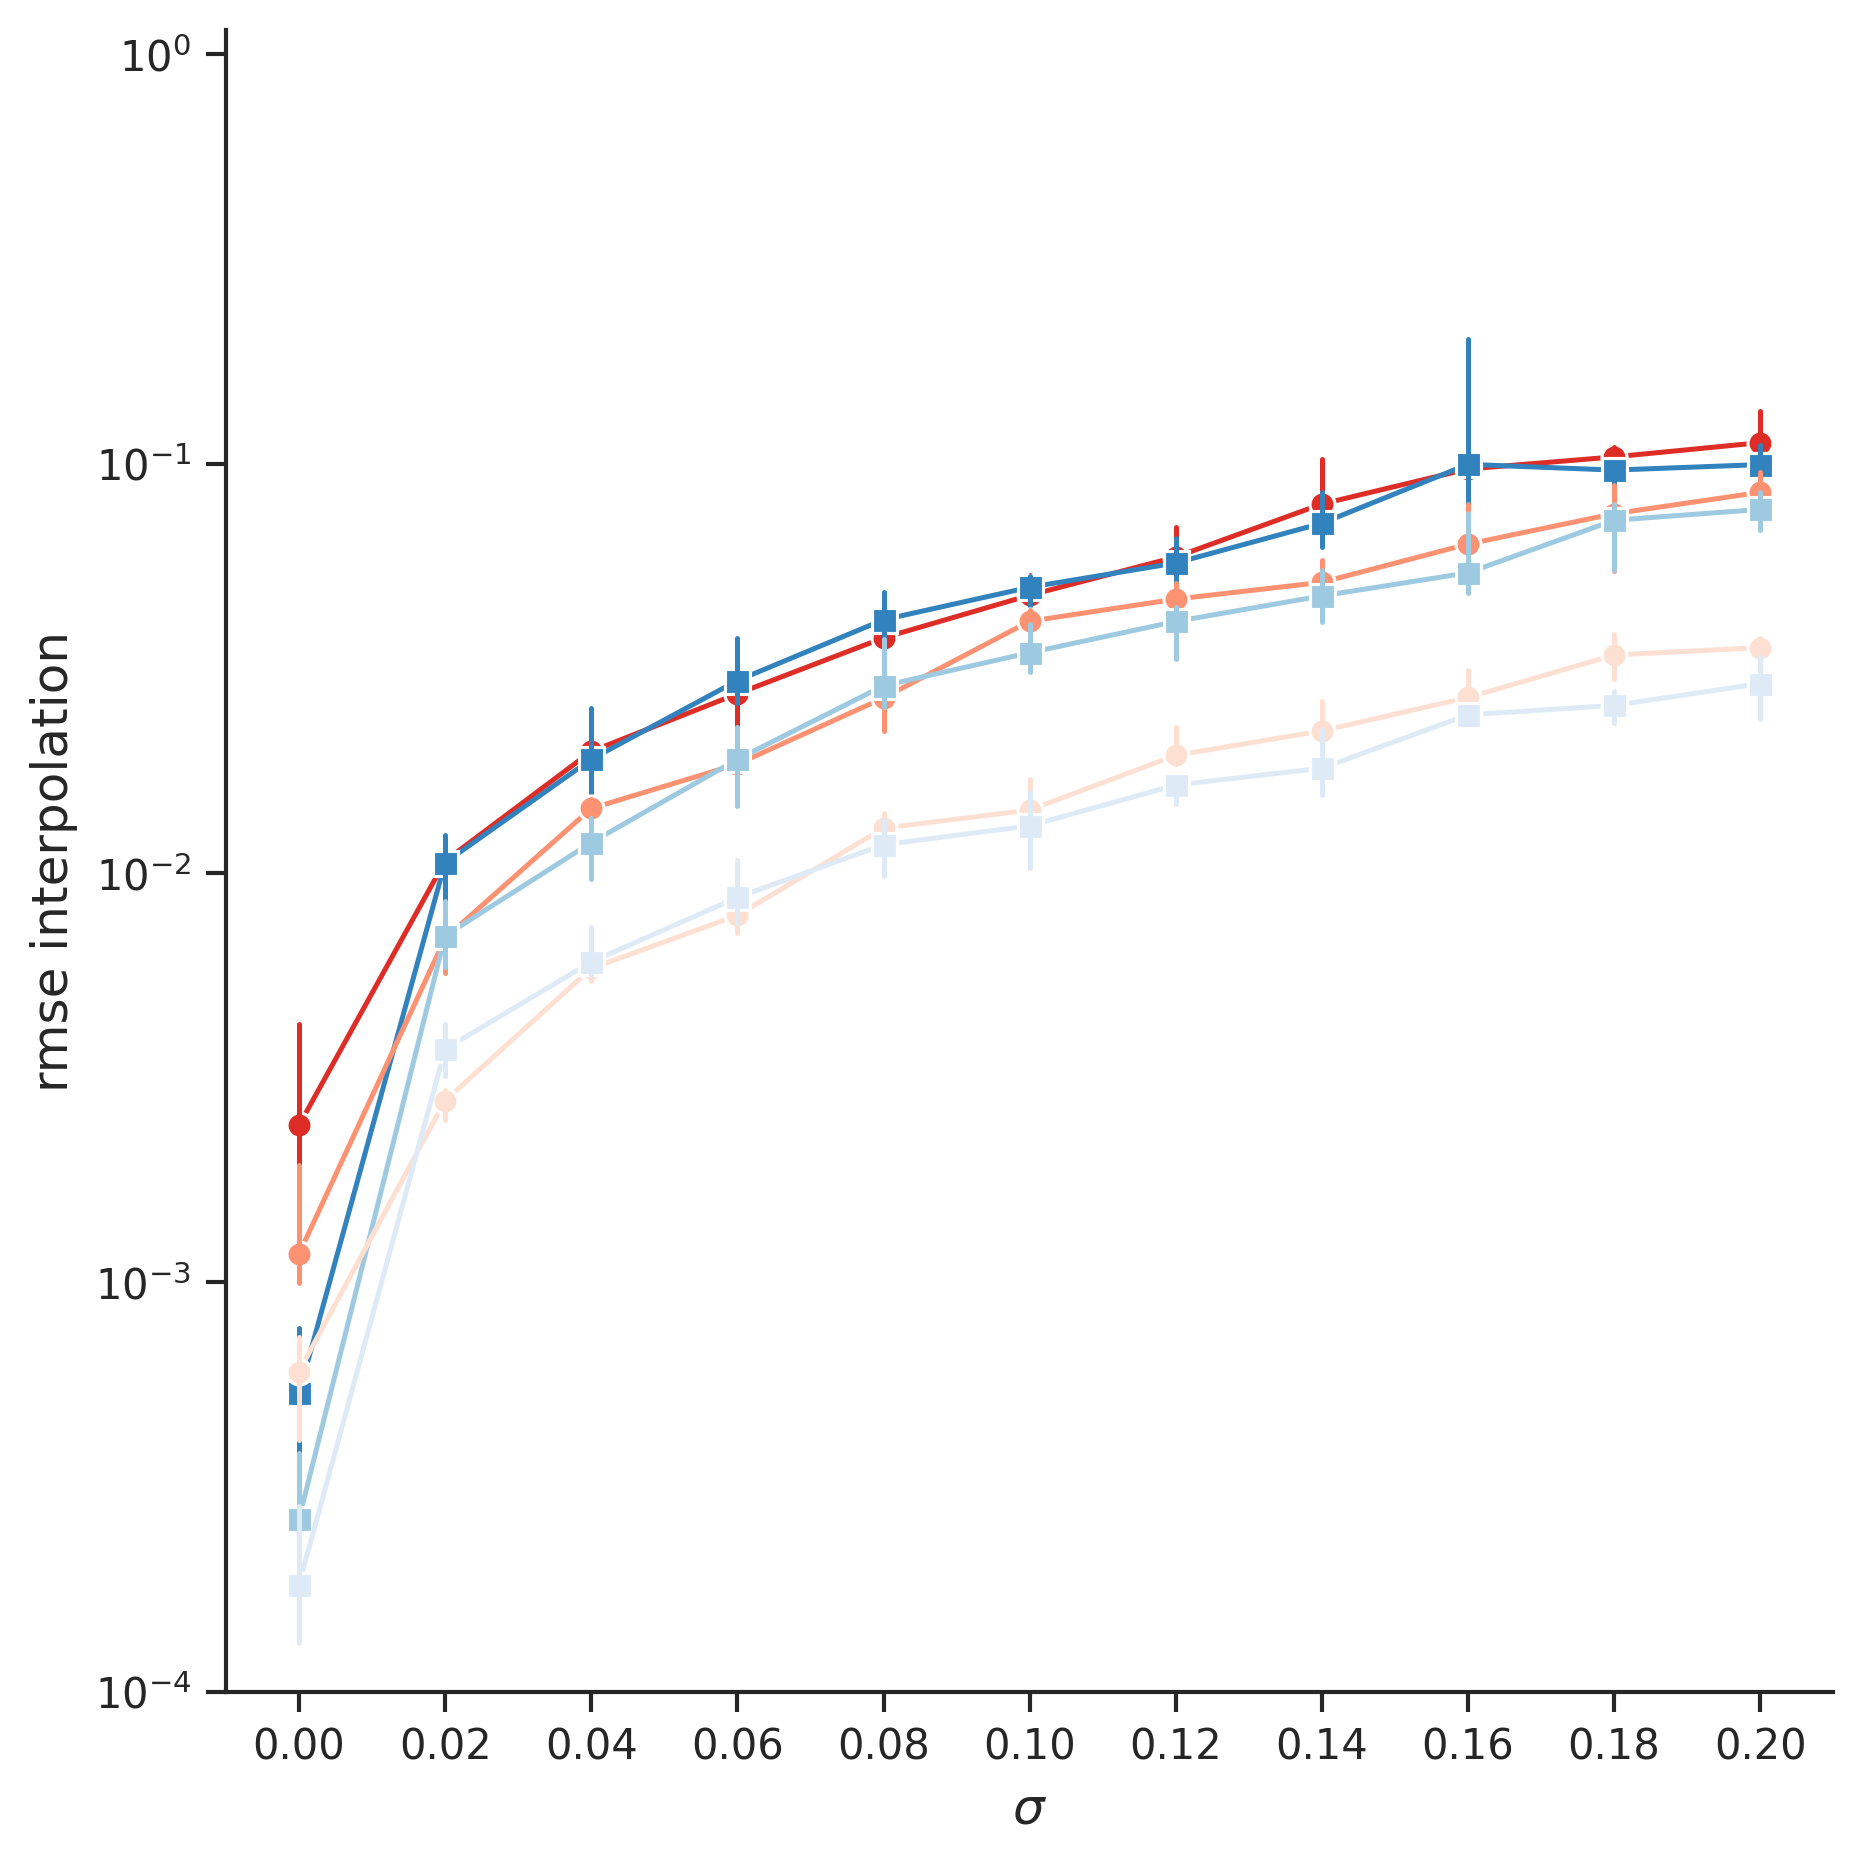

In [5]:
#Plot tanh interpolations

#tanh - rmse interpolation
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_tanh_inter[combined_tanh_inter['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_interp.', hue='error_interp.', style='error_interp.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_interp.'], markers['rmse_mdl_interp.']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log")
xtick_labels=np.arange(0.0,0.22,0.02)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax)
sns.despine()
plt.tight_layout()

name_fig='all_interpolations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

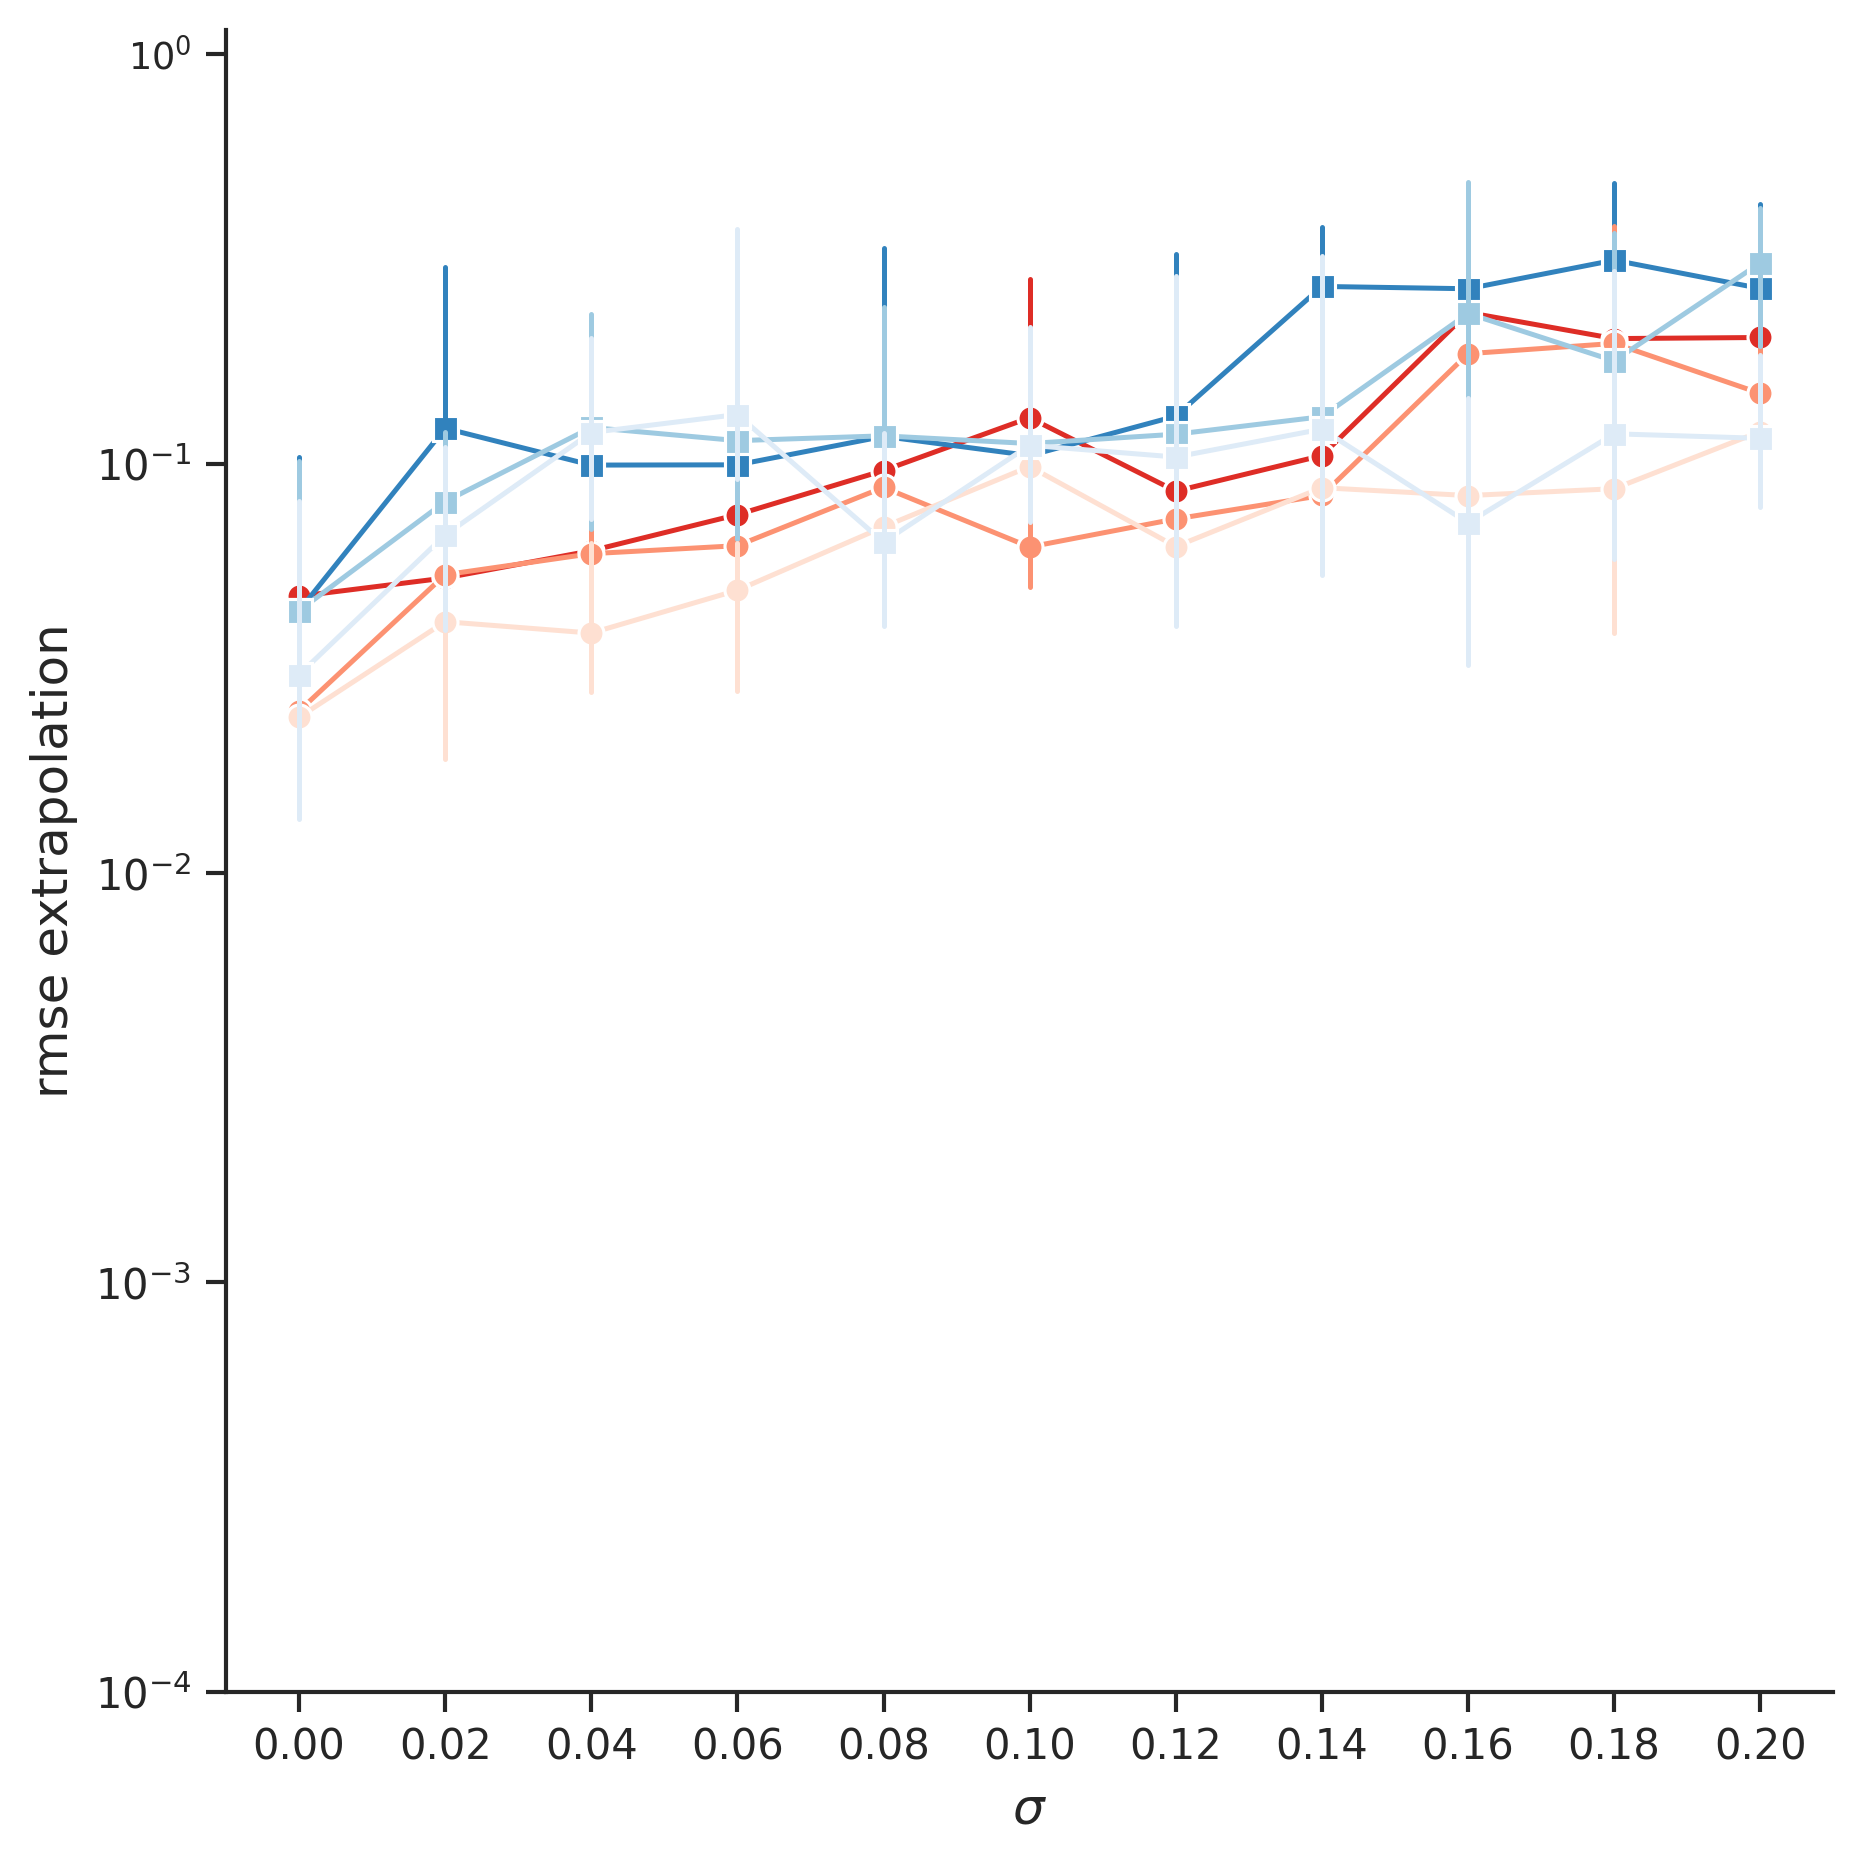

In [6]:
#Plot tanh extrapolations

#tanh - rmse extrapolation
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_tanh_extra[combined_tanh_extra['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_extrap.', hue='error_extrap.', style='error_extrap.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_interp.'], markers['rmse_mdl_interp.']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log")
xtick_labels=np.arange(0.0,0.22,0.02)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax)
sns.despine()
plt.tight_layout()

name_fig='all_extrapolations_tanh' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

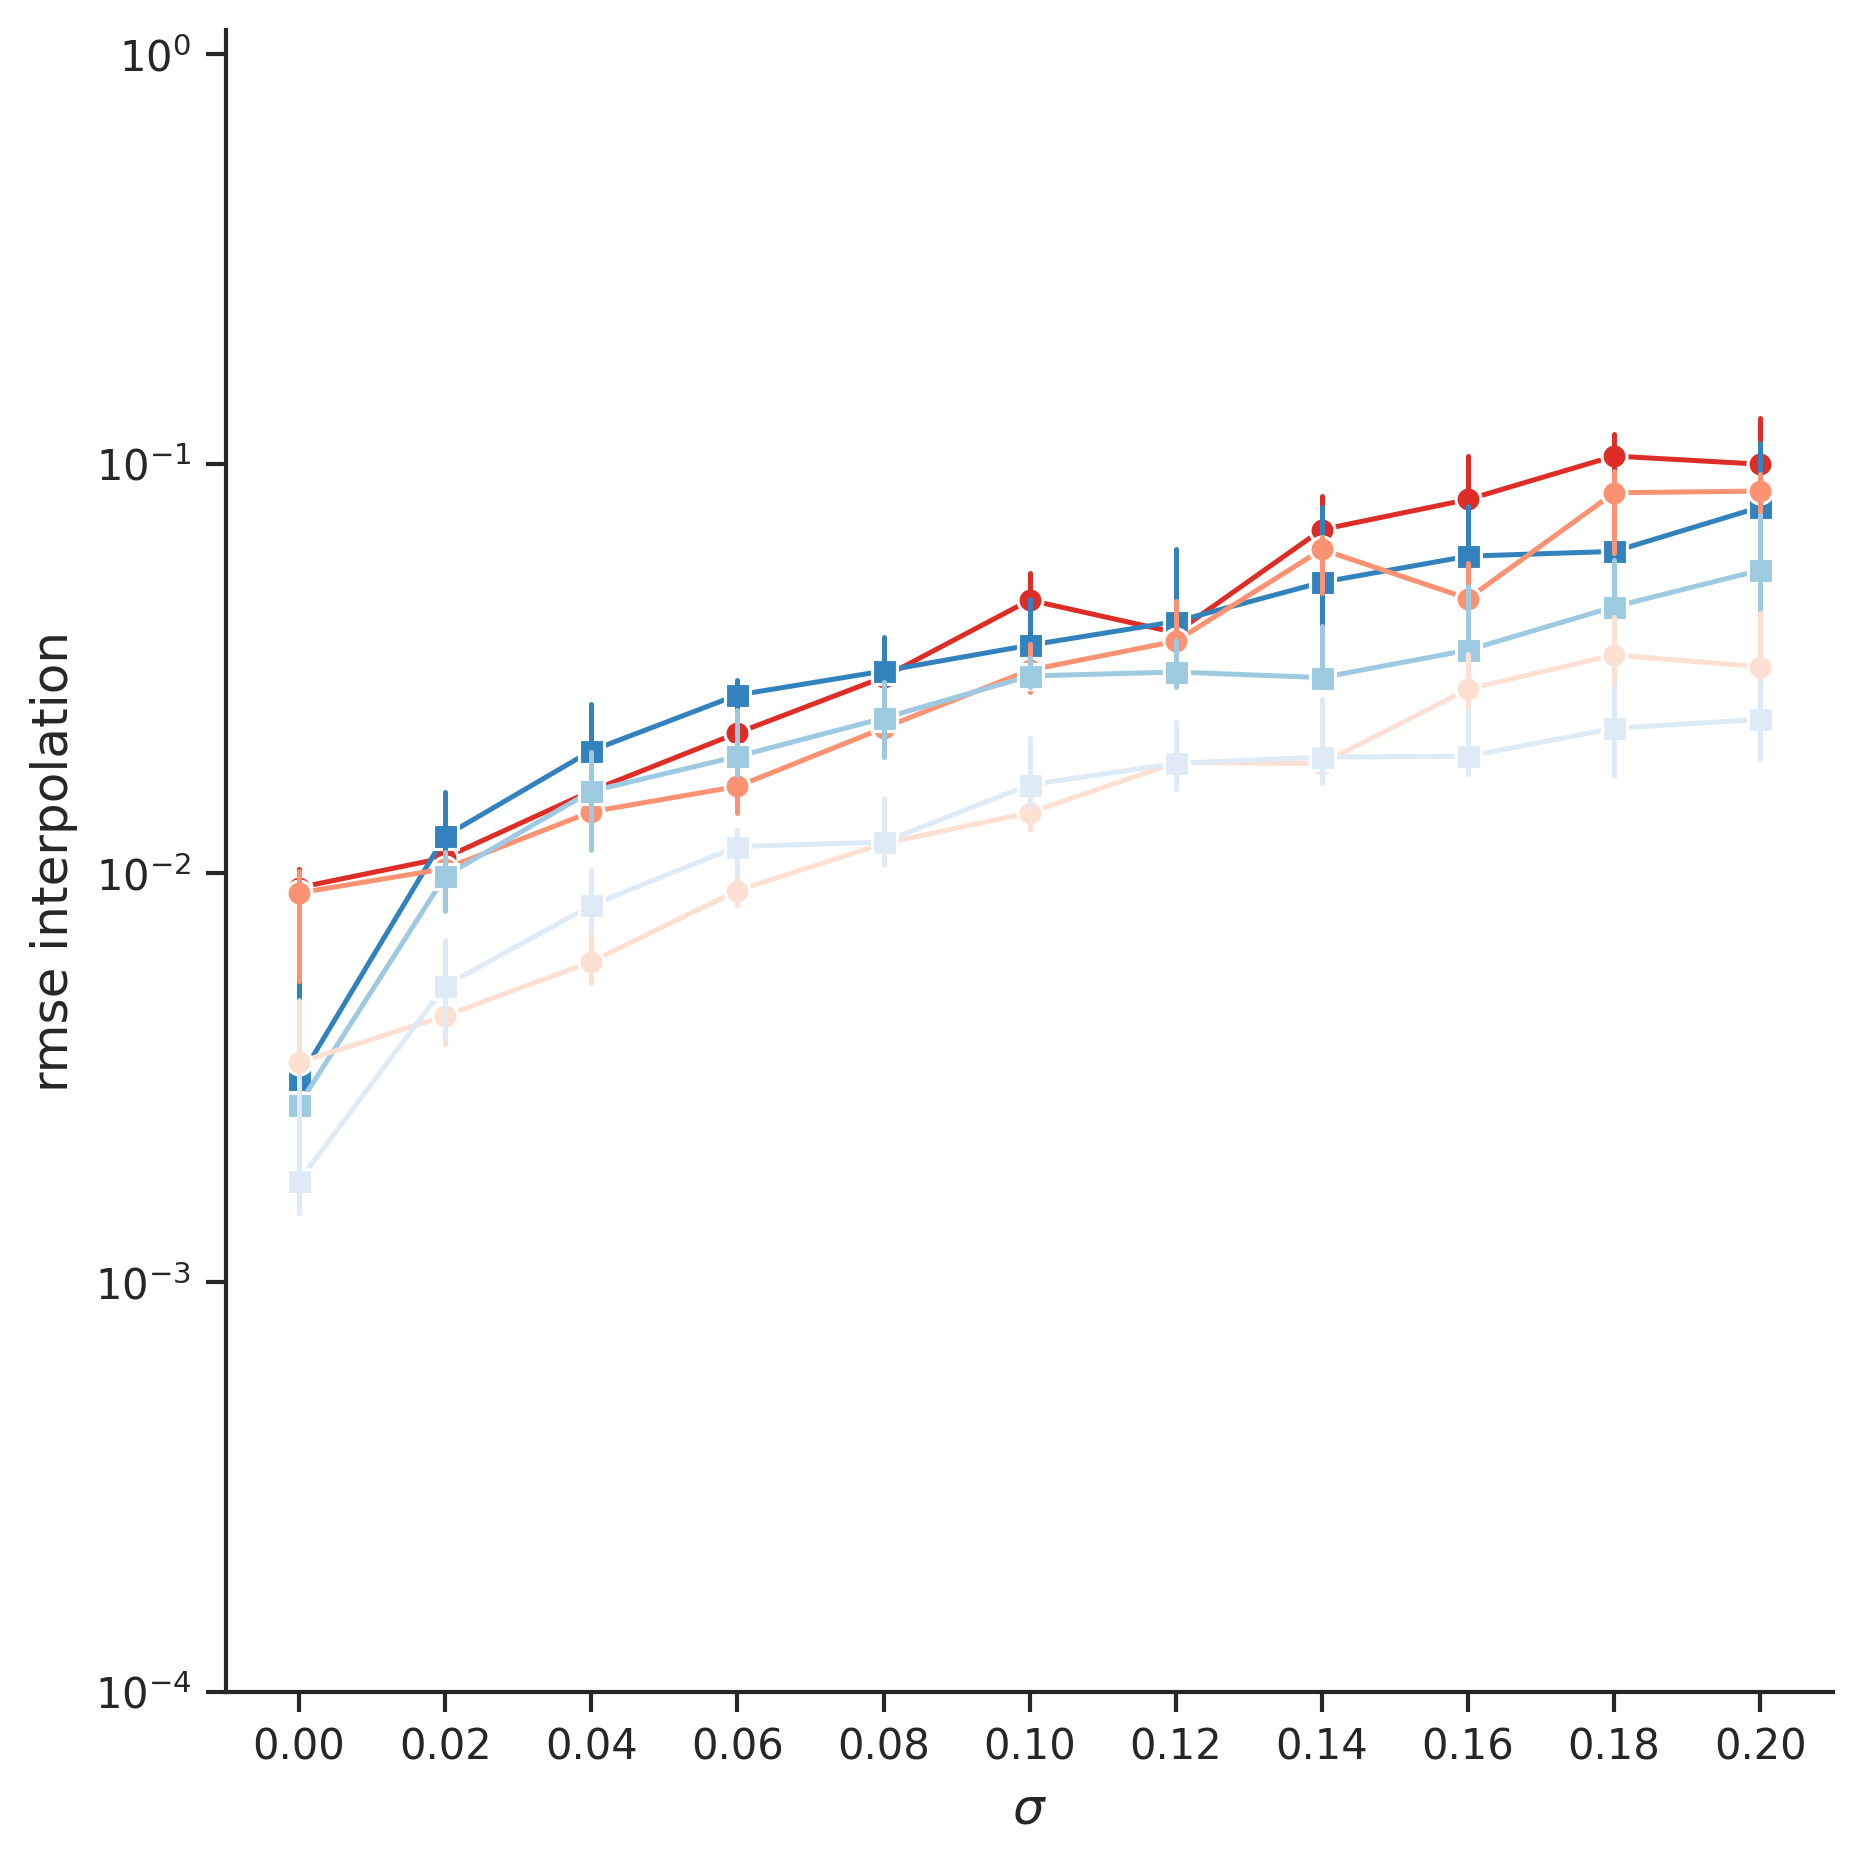

In [7]:
#Plot leaky interpolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_inter[combined_leaky_inter['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_interp.', hue='error_interp.', style='error_interp.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_interp.'], markers['rmse_mdl_interp.']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log")
xtick_labels=np.arange(0.0,0.22,0.02)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax)
sns.despine()
plt.tight_layout()

name_fig='all_interpolations_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------

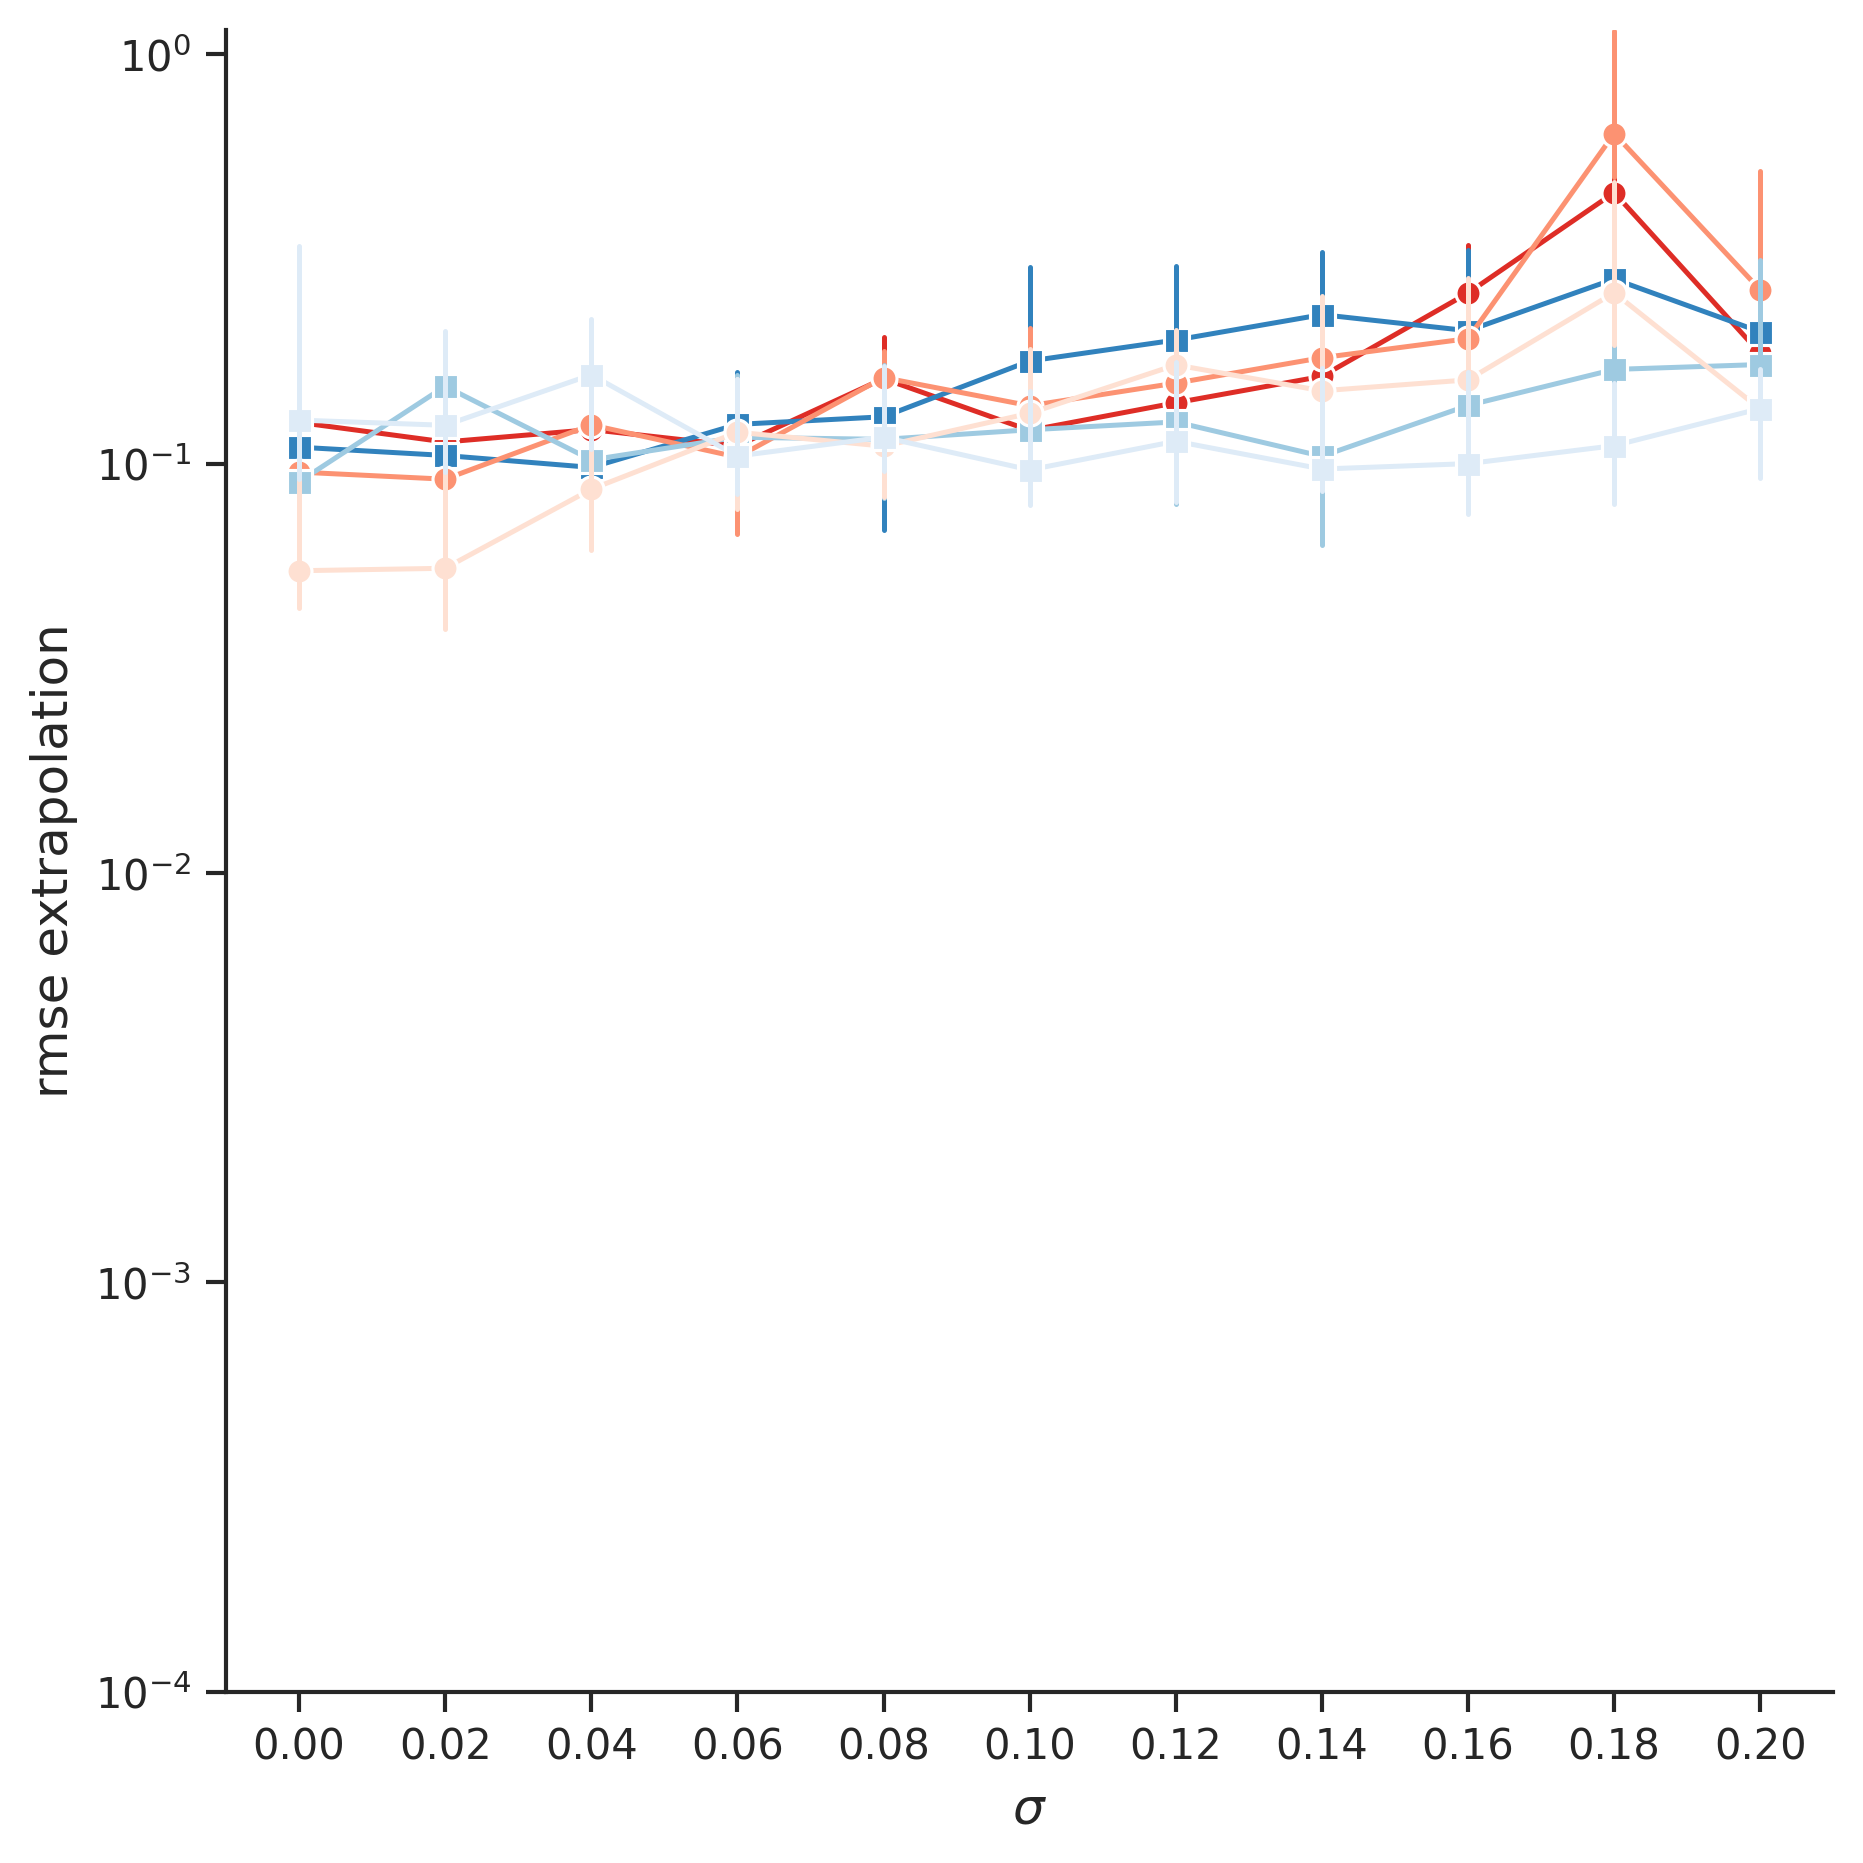

In [8]:
#Plot leaky extrapolations
fig=figure(figsize=(width,height), dpi=300)

for resolution in resolutions:
    data = combined_leaky_extra[combined_leaky_extra['resolution'] == resolution]
    sns.lineplot(
        data=data, x='sigma', y='value_extrap.', hue='error_extrap.', style='error_extrap.',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_interp.'], markers['rmse_mdl_interp.']], dashes=False, markersize=m_size, legend=False, 
        palette=colors[resolution])

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log")
xtick_labels=np.arange(0.0,0.22,0.02)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax)
sns.despine()
plt.tight_layout()

name_fig='all_extrapolationss_leaky' 
plt.savefig(output_path+name_fig + '.svg',dpi=300)
plt.savefig(output_path+name_fig + '.png',dpi=300)

#------------------------------------------------------------------------------------------------------------------------